# 05 — Approach II rule-based typing (interactive, versioned)

This notebook is designed for parameter experiments. Change `MIN_POSITIVE_GENES` (e.g. 2, 3, 4), rerun the rule, and each saved result receives a distinct tag so previous results are never overwritten.

In [12]:
# ============================================================
# Dataset_02 CosMx — shared Jupyter initialization
# ============================================================
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

CURRENT_DIR = Path.cwd().resolve()

def find_project_root(start: Path) -> Path:
    """Find the nearest parent containing both src/ and data/."""
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root from {start}. "
        "Expected a parent containing src/ and data/."
    )

PROJECT_ROOT = find_project_root(CURRENT_DIR)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPATIAL_DIR = PROJECT_ROOT / "data" / "spatial"
RESULTS_DIR = PROJECT_ROOT / "results"
CONFIG_DIR = PROJECT_ROOT / "config"

sc.settings.verbosity = 2

print("=" * 70)
print("Dataset_02 CosMx Jupyter environment")
print("=" * 70)
print("Notebook directory :", CURRENT_DIR)
print("Project root       :", PROJECT_ROOT)
print("Python             :", sys.executable)
print("src exists         :", (PROJECT_ROOT / "src").exists())
print("raw data exists    :", RAW_DIR.exists())
print("processed exists   :", PROCESSED_DIR.exists())
print("spatial exists     :", SPATIAL_DIR.exists())


Dataset_02 CosMx Jupyter environment
Notebook directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/jupyter-2
Project root       : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python             : /home/jqu/.conda/envs/spatialdata/bin/python
src exists         : True
raw data exists    : True
processed exists   : True
spatial exists     : True


In [13]:
from scipy import sparse
from config.markers import MARKER_PANEL
from src.typing import detection_rate

# ============================================================
# Approach-I input selection — EDIT HERE
# ============================================================
USE_APPROACH_I_VARIANT = False
APPROACH_I_TAG = "r0.6_manual"
APPROACH_I_VARIANT = RESULTS_DIR / "FOV46" / "approach_i_variants" / APPROACH_I_TAG / f"GSM9046088_FOV46_approach_i_{APPROACH_I_TAG}.h5ad"
APPROACH_I_PRODUCTION = RESULTS_DIR / "FOV46" / "GSM9046088_FOV46_approach_i.h5ad"
APPROACH_I_INPUT = APPROACH_I_VARIANT if USE_APPROACH_I_VARIANT else APPROACH_I_PRODUCTION

print("Approach-I input:", APPROACH_I_INPUT)
print("Exists          :", APPROACH_I_INPUT.exists())
if not APPROACH_I_INPUT.exists():
    raise FileNotFoundError(APPROACH_I_INPUT)

a = sc.read_h5ad(APPROACH_I_INPUT)
print(a)
print("Approach I labels:", a.obs["cell_type_scanpy"].value_counts())


Approach-I input: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/GSM9046088_FOV46_approach_i.h5ad
Exists          : True
AnnData object with n_obs × n_vars = 938 × 1000
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'n_genes_by_counts', 'total_counts', 'control_counts', 'control_fraction', 'qc_cell_area', 'qc_low_count_within_fov', 'qc_low_gene_within_fov', 'qc_pass', 'leiden_r0.1', 'leiden_r0.2', 'leiden_r0.3', 'leiden_r0.4', 'leiden_r0.5', 'leiden_r0.6', 'leiden_r0.7', 'leiden_r0.8', 'leiden_r0.9', 'leiden_r1', 'leiden', 'cell_type_scanpy'
    var: 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'is_

## Experiment parameter
`RUN_TAG` defaults to `min3`, `min2`, etc. You can add a descriptive suffix such as `min3_v2`.

## Rule-threshold sensitivity sweep

Use this section to test several **minimum numbers of positive marker genes** before choosing one for the final Approach II annotation. `MIN_POSITIVE_GENES = 4` means **at least 4 available marker genes have raw count > 0**. Results are kept in separate columns/tags so they do not overwrite one another.


,run_tag,min_positive_genes,n_assigned,assigned_fraction,n_unassigned,unassigned_fraction,n_ambiguous,ambiguous_fraction,n_available_cell_types
0,min2,2,310,0.330490,84,0.089552,544,0.579957,10
1,min3,3,431,0.459488,331,0.352878,176,0.187633,9
2,min4,4,256,0.272921,657,0.700426,25,0.026652,4
3,min5,5,63,0.067164,874,0.931770,1,0.001066,2


,min2,min3,min4,min5
Ambiguous,544,176,25,1
Endothelial,3,1,0,0
Epithelial,47,63,39,0
Fibroblast,36,91,71,8
Macrophage,77,159,145,55
Mural,0,0,1,0
Myeloid,1,0,0,0
Plasma_cell,143,117,0,0
T_cell,2,0,0,0
Tumor_epithelial,1,0,0,0


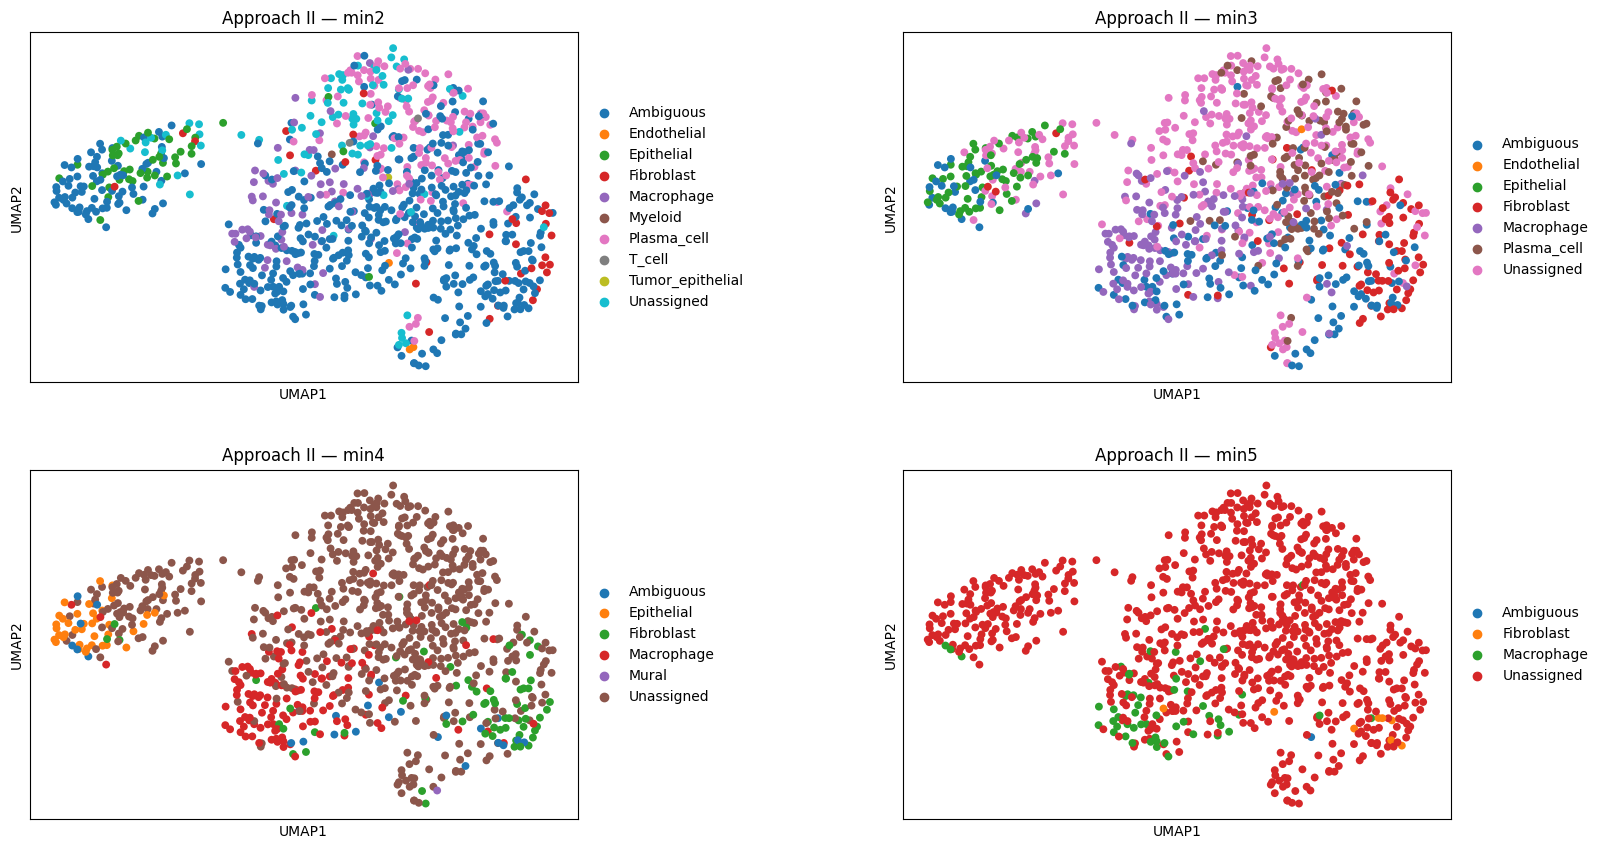

In [14]:
# ============================================================
# OPTIONAL: compare several rule thresholds before choosing one
# ============================================================
from scipy import sparse

TEST_MIN_POSITIVE_GENES = [2, 3, 4, 5]
LAYER = "counts"

if LAYER not in a.layers:
    raise KeyError(f"Required raw-count layer {LAYER!r} is missing.")


def run_rule_typing(data, min_positive_genes, marker_panel=MARKER_PANEL, layer="counts"):
    """Run one rule threshold without overwriting results from other thresholds."""
    Xall = data.layers[layer]
    positives = {}
    n_positive_by_type = {}
    availability = []

    for cell_type, genes in marker_panel.items():
        present = [g for g in genes if g in data.var_names]
        missing = [g for g in genes if g not in data.var_names]
        available = len(present) >= min_positive_genes

        availability.append({
            "cell_type": cell_type,
            "n_requested": len(genes),
            "n_present": len(present),
            "min_positive_genes": min_positive_genes,
            "available": available,
            "present": ",".join(present),
            "missing": ",".join(missing),
        })

        if not available:
            positives[cell_type] = np.zeros(data.n_obs, dtype=bool)
            n_positive_by_type[cell_type] = np.zeros(data.n_obs, dtype=int)
            continue

        idx = [data.var_names.get_loc(g) for g in present]
        x = Xall[:, idx]
        x = x.toarray() if sparse.issparse(x) else np.asarray(x)
        npos = np.asarray((x > 0).sum(axis=1)).ravel()
        n_positive_by_type[cell_type] = npos
        positives[cell_type] = npos >= min_positive_genes

    cell_types = list(marker_panel)
    mat = np.column_stack([positives[ct] for ct in cell_types])
    n_panels = mat.sum(axis=1)

    labels = np.full(data.n_obs, "Unassigned", dtype=object)
    one = n_panels == 1
    labels[one] = np.asarray(cell_types, dtype=object)[mat[one].argmax(axis=1)]
    labels[n_panels > 1] = "Ambiguous"

    return {
        "labels": labels,
        "n_panels": n_panels,
        "availability": pd.DataFrame(availability),
        "n_positive_by_type": n_positive_by_type,
    }


sweep_results = {}
sweep_summary = []

for n_gene in TEST_MIN_POSITIVE_GENES:
    tag = f"min{n_gene}"
    result = run_rule_typing(a, n_gene, layer=LAYER)
    sweep_results[tag] = result

    col = f"cell_type_rule_{tag}"
    a.obs[col] = pd.Categorical(result["labels"])

    counts = a.obs[col].value_counts(dropna=False)
    sweep_summary.append({
        "run_tag": tag,
        "min_positive_genes": n_gene,
        "n_assigned": int((~a.obs[col].astype(str).isin(["Unassigned", "Ambiguous"])).sum()),
        "assigned_fraction": float((~a.obs[col].astype(str).isin(["Unassigned", "Ambiguous"])).mean()),
        "n_unassigned": int((a.obs[col].astype(str) == "Unassigned").sum()),
        "unassigned_fraction": float((a.obs[col].astype(str) == "Unassigned").mean()),
        "n_ambiguous": int((a.obs[col].astype(str) == "Ambiguous").sum()),
        "ambiguous_fraction": float((a.obs[col].astype(str) == "Ambiguous").mean()),
        "n_available_cell_types": int(result["availability"]["available"].sum()),
    })

sweep_summary_df = pd.DataFrame(sweep_summary)
display(sweep_summary_df)

# Compare label distributions across thresholds.
label_count_table = pd.DataFrame({
    tag: a.obs[f"cell_type_rule_{tag}"].value_counts(dropna=False)
    for tag in sweep_results
}).fillna(0).astype(int)

display(label_count_table)

# UMAP comparison of all tested thresholds.
cols = [f"cell_type_rule_min{x}" for x in TEST_MIN_POSITIVE_GENES]
sc.pl.umap(
    a,
    color=cols,
    frameon=True,
    ncols=2,
    wspace=0.45,
    legend_loc="right margin",
    title=[f"Approach II — min{x}" for x in TEST_MIN_POSITIVE_GENES],
)


In [15]:
# ============================================================
# Choose ONE threshold for the final Approach-II annotation
# EDIT HERE after inspecting the sensitivity sweep above.
# ============================================================
MIN_POSITIVE_GENES = 3

# Default tag automatically distinguishes min2/min3/min4/min5 outputs.
# You can add a suffix when testing another marker panel or rule variant, e.g.
# RUN_TAG = f"min{MIN_POSITIVE_GENES}_panelB"
RUN_TAG = f"min{MIN_POSITIVE_GENES}"
LAYER = "counts"
RULE_COL = f"cell_type_rule_{RUN_TAG}"

print("Rule     : >=", MIN_POSITIVE_GENES, "available marker genes with raw count > 0")
print("RUN_TAG  :", RUN_TAG)
print("RULE_COL :", RULE_COL)
print("Output subdirectory will be:")
print(RESULTS_DIR / "FOV46" / "approach_ii_variants" / RUN_TAG)


Rule     : >= 3 available marker genes with raw count > 0
RUN_TAG  : min3
RULE_COL : cell_type_rule_min3
Output subdirectory will be:
/research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min3


In [16]:
# Marker availability and detection rates.
rates=[]; availability=[]; positives={}; n_positive_by_type={}
Xall=a.layers[LAYER]
for cell_type, genes in MARKER_PANEL.items():
    present=[g for g in genes if g in a.var_names]
    missing=[g for g in genes if g not in a.var_names]
    available=len(present)>=MIN_POSITIVE_GENES
    availability.append(dict(cell_type=cell_type,n_requested=len(genes),n_present=len(present),min_positive_genes=MIN_POSITIVE_GENES,available=available,present=",".join(present),missing=",".join(missing)))
    for gene,value in detection_rate(a,genes,layer=LAYER).items(): rates.append(dict(cell_type=cell_type,gene=gene,detection_rate=value))
    if not available:
        positives[cell_type]=np.zeros(a.n_obs,dtype=bool); n_positive_by_type[cell_type]=np.zeros(a.n_obs,dtype=int); continue
    idx=[a.var_names.get_loc(g) for g in present]; x=Xall[:,idx]
    x=x.toarray() if sparse.issparse(x) else np.asarray(x)
    npos=np.asarray((x>0).sum(axis=1)).ravel()
    n_positive_by_type[cell_type]=npos
    positives[cell_type]=npos>=MIN_POSITIVE_GENES

availability_df=pd.DataFrame(availability)
display(availability_df)

,cell_type,n_requested,n_present,min_positive_genes,available,present,missing
0,Epithelial,4,4,3,True,"EPCAM,KRT8,KRT18,KRT19",
1,AT1,4,1,3,False,CAV1,"AGER,CAV2,PDPN"
2,AT2,5,0,3,False,,"SFTPA1,SFTPA2,SFTPB,SFTPC,NAPSA"
3,Tumor_epithelial,5,3,3,True,"CEACAM6,KRT17,MKI67","CEACAM5,MUC1"
4,T_cell,4,2,3,False,"CD3D,CD3E","TRAC,CD247"
5,B_cell,4,3,3,True,"MS4A1,CD79A,CD37",CD79B
6,Plasma_cell,4,3,3,True,"MZB1,JCHAIN,IGHG1",SDC1
7,Myeloid,4,3,3,True,"TYROBP,FCER1G,AIF1",LST1
8,Macrophage,5,5,3,True,"C1QA,C1QB,C1QC,APOE,CD68",
9,Endothelial,4,3,3,True,"PECAM1,VWF,KDR",EMCN


In [17]:
# Assign Unassigned / one cell type / Ambiguous.
cell_types=list(MARKER_PANEL)
mat=np.column_stack([positives[ct] for ct in cell_types])
n_panels=mat.sum(axis=1)
labels=np.full(a.n_obs,"Unassigned",dtype=object)
one=n_panels==1
labels[one]=np.asarray(cell_types,dtype=object)[mat[one].argmax(axis=1)]
labels[n_panels>1]="Ambiguous"

RULE_COL=f"cell_type_rule_{RUN_TAG}"
a.obs[RULE_COL]=pd.Categorical(labels)
a.obs[f"rule_n_positive_panels_{RUN_TAG}"]=n_panels
for ct in cell_types:
    a.obs[f"rule_{ct}_n_positive_genes_{RUN_TAG}"]=n_positive_by_type[ct]

print("RULE_COL:",RULE_COL)
display(a.obs[RULE_COL].value_counts(dropna=False))

RULE_COL: cell_type_rule_min3


cell_type_rule_min3
Unassigned     331
Ambiguous      176
Macrophage     159
Plasma_cell    117
Fibroblast      91
Epithelial      63
Endothelial      1
Name: count, dtype: int64

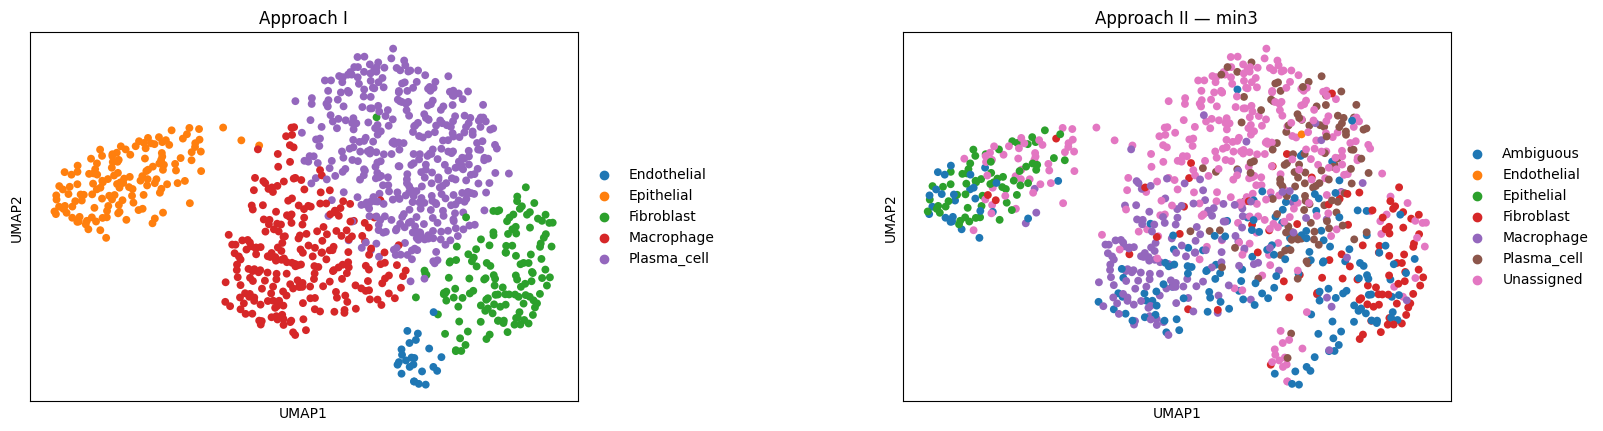

In [18]:
# UMAP — same coordinates/theme as Approach I.
sc.pl.umap(a,color=["cell_type_scanpy",RULE_COL],frameon=True,wspace=.45,legend_loc="right margin",title=["Approach I",f"Approach II — {RUN_TAG}"])

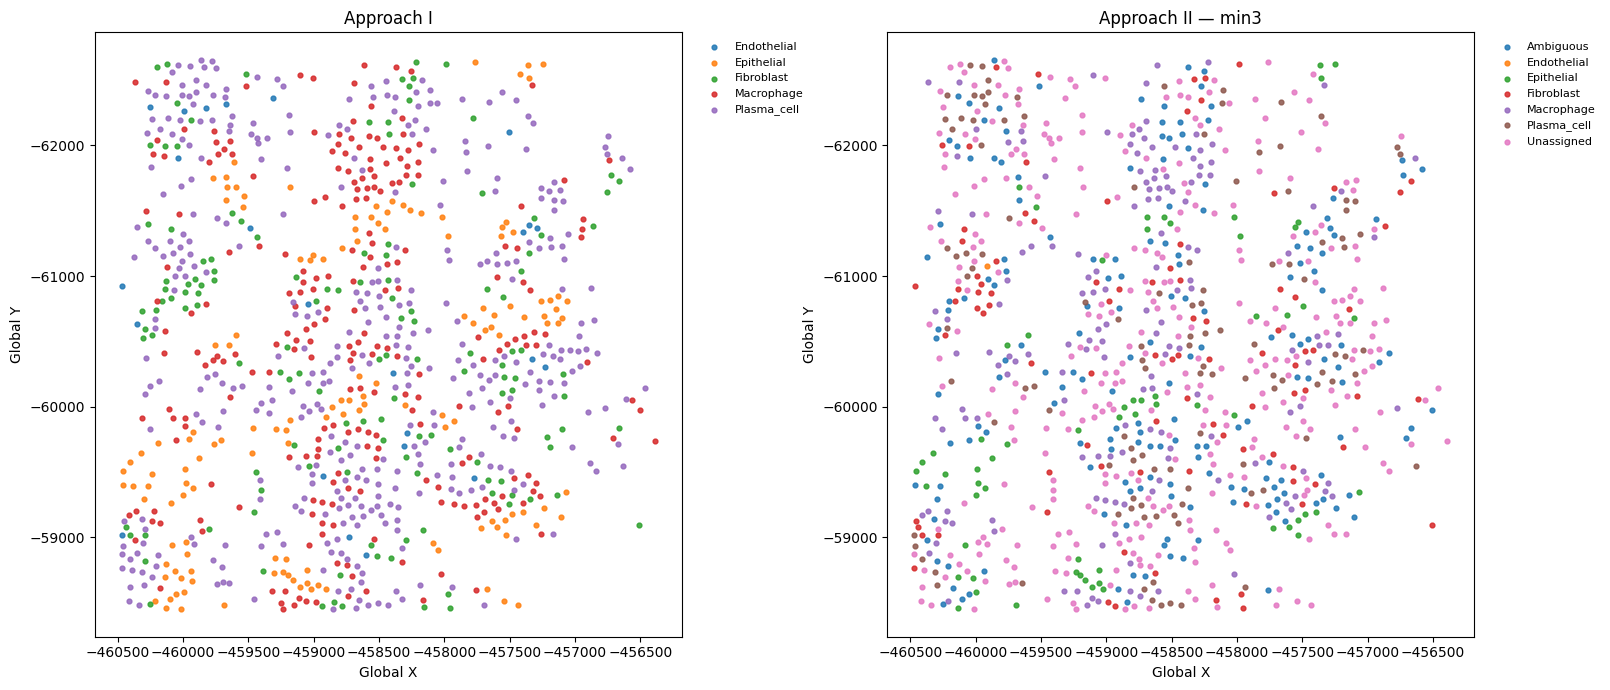

In [19]:
# Spatial coordinate comparison.
xy=np.asarray(a.obsm["spatial"])
fig,axes=plt.subplots(1,2,figsize=(16,7))
for ax,col,title in zip(axes,["cell_type_scanpy",RULE_COL],["Approach I",f"Approach II — {RUN_TAG}"]):
    lab=a.obs[col].astype("category")
    for cat in lab.cat.categories:
        m=lab.astype(str).to_numpy()==str(cat); ax.scatter(xy[m,0],xy[m,1],s=12,label=str(cat),alpha=.85)
    ax.set_aspect("equal");ax.invert_yaxis();ax.set_xlabel("Global X");ax.set_ylabel("Global Y");ax.set_title(title)
    ax.legend(bbox_to_anchor=(1.02,1),loc="upper left",frameon=False,fontsize=8)
plt.tight_layout();plt.show()

In [20]:
# Quick Approach-I × current Approach-II contingency table.
ct=pd.crosstab(a.obs["cell_type_scanpy"],a.obs[RULE_COL])
frac=pd.crosstab(a.obs["cell_type_scanpy"],a.obs[RULE_COL],normalize="index")
display(ct); display(frac.round(3))

cell_type_rule_min3,Ambiguous,Endothelial,Epithelial,Fibroblast,Macrophage,Plasma_cell,Unassigned
cell_type_scanpy,,,,,,,
Endothelial,7,0,0,1,0,2,14
Epithelial,26,0,63,3,3,0,46
Fibroblast,51,0,0,63,5,2,16
Macrophage,59,0,0,8,128,5,42
Plasma_cell,33,1,0,16,23,108,213


cell_type_rule_min3,Ambiguous,Endothelial,Epithelial,Fibroblast,Macrophage,Plasma_cell,Unassigned
cell_type_scanpy,,,,,,,
Endothelial,0.292,0.000,0.000,0.042,0.000,0.083,0.583
Epithelial,0.184,0.000,0.447,0.021,0.021,0.000,0.326
Fibroblast,0.372,0.000,0.000,0.460,0.036,0.015,0.117
Macrophage,0.244,0.000,0.000,0.033,0.529,0.021,0.174
Plasma_cell,0.084,0.003,0.000,0.041,0.058,0.274,0.541


## Save this experiment without overwriting earlier runs
Outputs include `RUN_TAG` in the filename/directory. You can therefore save `min2`, `min3`, `min4`, etc. and compare them later.

## Save all threshold variants for Notebook 06

This is the cross-notebook handoff. Set `SAVE_ALL_SWEEP_VARIANTS = True` only after inspecting the sweep. Each threshold is written to its own directory and filename.


In [21]:
# ============================================================
# Save ALL tested Approach-II variants (cross-notebook handoff)
# ============================================================
# Keep False while exploring. Set True only after you are satisfied with the
# threshold sweep. This writes one independent h5ad per tested threshold so
# Notebook 06 can discover and compare them without relying on Notebook 05 memory.
SAVE_ALL_SWEEP_VARIANTS = True   # Default: False

VARIANT_ROOT = RESULTS_DIR / "FOV46" / "approach_ii_variants"

print("SAVE_ALL_SWEEP_VARIANTS:", SAVE_ALL_SWEEP_VARIANTS)
print("Variant root:", VARIANT_ROOT)
print("\nPlanned variant files:")
for n_gene in TEST_MIN_POSITIVE_GENES:
    tag = f"min{n_gene}"
    path = VARIANT_ROOT / tag / f"GSM9046088_FOV46_approach_i_ii_{tag}.h5ad"
    print(f"  {tag:6s} -> {path}")

saved_variant_files = {}

if SAVE_ALL_SWEEP_VARIANTS:
    for n_gene in TEST_MIN_POSITIVE_GENES:
        tag = f"min{n_gene}"
        rule_col = f"cell_type_rule_{tag}"
        result = sweep_results[tag]

        variant_dir = VARIANT_ROOT / tag
        table_dir = variant_dir / "tables"
        figure_dir = variant_dir / "figures"
        variant_dir.mkdir(parents=True, exist_ok=True)
        table_dir.mkdir(parents=True, exist_ok=True)
        figure_dir.mkdir(parents=True, exist_ok=True)

        output_file = variant_dir / f"GSM9046088_FOV46_approach_i_ii_{tag}.h5ad"

        # Save a self-contained copy for this threshold. Keep Approach I plus the
        # selected Approach-II column; remove other sweep rule columns to make the
        # identity of each variant unambiguous.
        obj = a.copy()
        other_rule_cols = [
            c for c in obj.obs.columns
            if c.startswith("cell_type_rule_min") and c != rule_col
        ]
        if other_rule_cols:
            obj.obs.drop(columns=other_rule_cols, inplace=True)

        obj.uns["approach_ii_rule_run_tag"] = tag
        obj.uns["approach_ii_min_positive_genes"] = int(n_gene)
        obj.uns["approach_ii_rule_column"] = rule_col
        obj.write_h5ad(output_file, compression="gzip")

        # Variant-specific diagnostics.
        result["availability"].to_csv(
            table_dir / f"rule_marker_availability_{tag}.csv", index=False
        )
        obj.obs[rule_col].value_counts(dropna=False).to_csv(
            table_dir / f"rule_label_counts_{tag}.csv"
        )

        # Save the sweep summary in every variant directory for provenance.
        sweep_summary_df.to_csv(
            table_dir / "approach_ii_threshold_sweep_summary.csv", index=False
        )
        label_count_table.to_csv(
            table_dir / "approach_ii_threshold_label_counts.csv"
        )

        saved_variant_files[tag] = output_file
        print(f"Saved {tag}: {output_file}")
else:
    print("\nSAVE_ALL_SWEEP_VARIANTS=False — nothing written to disk.")
    print("Set it to True and rerun this cell when the sweep looks satisfactory.")


SAVE_ALL_SWEEP_VARIANTS: True
Variant root: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants

Planned variant files:
  min2   -> /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min2/GSM9046088_FOV46_approach_i_ii_min2.h5ad
  min3   -> /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min3/GSM9046088_FOV46_approach_i_ii_min3.h5ad
  min4   -> /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min4/GSM9046088_FOV46_approach_i_ii_min4.h5ad
  min5   -> /research/rgs01/home/clusterHome/jqu/activities/learni

In [22]:
# ============================================================
# Verify all Approach-II variant files
# ============================================================
VARIANT_ROOT = RESULTS_DIR / "FOV46" / "approach_ii_variants"

verification_rows = []
for n_gene in TEST_MIN_POSITIVE_GENES:
    tag = f"min{n_gene}"
    rule_col = f"cell_type_rule_{tag}"
    path = VARIANT_ROOT / tag / f"GSM9046088_FOV46_approach_i_ii_{tag}.h5ad"
    exists = path.exists()
    size_mb = path.stat().st_size / 1024**2 if exists else np.nan

    rule_present = False
    n_cells = np.nan
    if exists:
        test_obj = sc.read_h5ad(path)
        rule_present = rule_col in test_obj.obs.columns
        n_cells = test_obj.n_obs

    verification_rows.append({
        "run_tag": tag,
        "min_positive_genes": n_gene,
        "exists": exists,
        "size_mb": size_mb,
        "n_cells": n_cells,
        "expected_rule_column": rule_col,
        "rule_column_present": rule_present,
        "path": str(path),
    })

verification_df = pd.DataFrame(verification_rows)
display(verification_df)

if SAVE_ALL_SWEEP_VARIANTS:
    failed = verification_df.loc[
        ~(verification_df["exists"] & verification_df["rule_column_present"])
    ]
    if not failed.empty:
        raise RuntimeError(
            "One or more requested Approach-II variants failed verification:\n"
            + failed[["run_tag", "path"]].to_string(index=False)
        )
    print("All saved variants passed reload verification.")


,run_tag,min_positive_genes,exists,size_mb,n_cells,expected_rule_column,rule_column_present,path
0,min2,2,True,3.606168,938,cell_type_rule_min2,True,/research/rgs01/home/clusterHome/jqu/activitie...
1,min3,3,True,3.606106,938,cell_type_rule_min3,True,/research/rgs01/home/clusterHome/jqu/activitie...
2,min4,4,True,3.606115,938,cell_type_rule_min4,True,/research/rgs01/home/clusterHome/jqu/activitie...
3,min5,5,True,3.606169,938,cell_type_rule_min5,True,/research/rgs01/home/clusterHome/jqu/activitie...


All saved variants passed reload verification.
